<a href="https://colab.research.google.com/github/dmandache/IMPERANDI/blob/main/examples/demos/demo_light.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPERANDI × TCGA-LIHC — Light demo

A quick public walkthrough of IMPERANDI using three TCGA-LIHC patients. This version installs the **base package only** and demonstrates metadata ingestion and contrast-phase curation without image conversion, segmentation, or model downloads.

For the complete image-processing workflow, open `demo_full.ipynb`.

## 1. Install IMPERANDI

The IDC downloader is used only to fetch the public TCGA-LIHC DICOM subset.

In [1]:
%cd /content
![ -d /content/IMPERANDI/.git ] || git clone --depth 1 --branch main https://github.com/dmandache/IMPERANDI.git
%cd /content/IMPERANDI
!python -m pip install .
!python -m pip install idc-index


/content
Cloning into 'IMPERANDI'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (189/189), done.
remote: Total 206 (delta 11), reused 75 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (206/206), 3.28 MiB | 18.46 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/IMPERANDI
Processing /content/IMPERANDI
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 78.6 MB/s eta 0:00:00
  Created wheel for imperandi: filename=imperandi-0.0.1.dev1+g3f4d9916b-py3-none-any.whl size=207235 sha256=6f8b06b119db04384d427e0c01eef28a7255592a

## 2. Download the same three public patients used by both demos

`TCGA-BC-A10Y`, `TCGA-DD-A113`, and `TCGA-DD-A4NJ` are deliberately fixed so results can be compared between the light and full notebooks.

In [2]:
!python examples/benchmarks/download.py /content/TCGA-LIHC-demo \
  --patient TCGA-BC-A10Y \
  --patient TCGA-DD-A113 \
  --patient TCGA-DD-A4NJ

2026-10-10 15:19:22,670 - Disk size needed: 2.75 GB
2026-10-10 15:19:22,671 - Disk size available: 93.36 GB
2026-10-10 15:19:22,896 - Not using s5cmd sync as the destination folder is empty or sync or progress bar is not requested
2026-10-10 15:19:22,898 - Initial size of the directory: 0 bytes
2026-10-10 15:19:22,899 - Approximate size of the files that need to be downloaded: 2.75 GB
2026-10-10 15:19:46,912 - Successfully downloaded files to /content/TCGA-LIHC-demo
Saved download selection to /content/TCGA-LIHC-demo/idc_selection.csv


### Inspect the downloaded series

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

selection = pd.read_csv('/content/TCGA-LIHC-demo/idc_selection.csv')
display(selection[['PatientID','Modality','StudyInstanceUID','SeriesInstanceUID','series_size_MB']])
display(
    selection.groupby(['PatientID', 'Modality'])
    .agg(
        studies=('StudyInstanceUID', 'nunique'),
        series=('SeriesInstanceUID', 'nunique'),
    )
)

,PatientID,Modality,StudyInstanceUID,SeriesInstanceUID,series_size_MB
0,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.112954049272...,7.527276
1,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.146521872880...,4.557298
2,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.210105385864...,3.349438
3,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.222111668590...,4.557388
4,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.235620519037...,7.526258
...,...,...,...,...,...
87,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.312823803664...,57.948674
88,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.315096169381...,6.418184
89,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.345436872573...,34.862056
90,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.377152448922...,4.420734


studies  series
PatientID    Modality                 
TCGA-BC-A10Y MR              2      24
TCGA-DD-A113 CT              4      17
             MR              1      10
TCGA-DD-A4NJ CT              3      22
             MR              1      19

## 3. Ingest: DICOM → harmonized volume-level cohort

`imperandi ingest` parses the DICOM collection, reconstructs volume-level records, and runs the modality-specific metadata engines. The raw metadata evidence (for example `rule_phase`) is retained so the next task can resolve the canonical phase explicitly.

In [4]:
!mkdir -p /content/imperandi-demo/tables
!imperandi ingest \
  /content/TCGA-LIHC-demo \
  /content/imperandi-demo/tables \
  --manifest examples/demos/demo_manifest.yaml \
  --id_source tags \
  --patient_key_from PatientID \
  --study_id_from StudyInstanceUID \
  --series_id_from SeriesInstanceUID \
  --num_workers 2

2026-10-10 15:19:52 | INFO     | imperandi.cli | Running parse.py with arguments:
{   'archive_cache_dir': None,
    'archive_detect_sample_size': 128,
    'archive_max_depth': 3,
    'checkpoint_every_rows': 10000,
    'checkpoint_every_sec': 300,
    'command': 'ingest',
    'csv_path_out': None,
    'dry_run': False,
    'force_dicom_read': False,
    'id_source': 'tags',
    'keep_archive_cache': False,
    'log_file': None,
    'log_level': None,
    'manifest': 'examples/demos/demo_manifest.yaml',
    'num_workers': 2,
    'output_dir': '/content/imperandi-demo/tables',
    'patient_key_from': 'PatientID',
    'quiet': False,
    'resume': True,
    'root_path': '/content/TCGA-LIHC-demo',
    'series_id_from': 'SeriesInstanceUID',
    'snapshot_sample_size': 500,
    'snapshot_seed': 42,
    'snapshot_tags': False,
    'strict_resume': False,
    'study_id_from': 'StudyInstanceUID',
    'tags': '',
    'verbose': False}
2026-10-10 15:19:52 | INFO     | imperandi.cli | Running cle

### Inspect ingest outputs

In [5]:
raw = pd.read_csv('/content/imperandi-demo/tables/dicom_index.csv')
clean = pd.read_csv('/content/imperandi-demo/tables/dicom_index_clean.csv')

print(f'Parsed DICOM rows: {len(raw):,}')
print(f'Curated volume rows: {len(clean):,}')

print('Volumes by patient and modality:')
display(
    clean.groupby(['patient_key', 'Modality'])
    .agg(
        studies=('study_id', 'nunique'),
        series=('series_id', 'nunique'),
        volumes=('volume_id', 'nunique'),
    )
)

print('Representative curated volumes:')
clean_cols = [c for c in ['patient_key', 'date', 'Modality', 'SeriesDescription', 'volume_id'] if c in clean.columns]
display(clean[clean_cols].head(10))



Parsed DICOM rows: 5,931
Curated volume rows: 33
Volumes by patient and modality:


studies  series  volumes
patient_key  Modality                          
TCGA-BC-A10Y MR              2       4        4
TCGA-DD-A113 CT              2       5        6
             MR              1       6        9
TCGA-DD-A4NJ CT              2       6        6
             MR              1       7        8

Representative curated volumes:


,patient_key,date,Modality,SeriesDescription,volume_id
0,TCGA-BC-A10Y,1993-03-21,MR,VIBE 3D NEW 2002B,8e645fafd837e284d640f444a606d53608916369
1,TCGA-BC-A10Y,1993-03-21,MR,Subtraction_S11_S9_1,30d17d0c04eaf4f2862f554af44e42fa50e138af
2,TCGA-BC-A10Y,1993-03-21,MR,VIBE 3D NEW 2002B,74e6d13efd2a9cc8e61ffb1bb3e97938800a273a
3,TCGA-BC-A10Y,1993-05-01,MR,VIBE 3D NEW 2002B,3f3f02cda686c10767919269bc39d3396d4162f3
4,TCGA-DD-A113,1998-12-09,MR,improved IP/OP,8fc5aa6d8e71c0aa2dd10f69ff5bbe4204be4050
5,TCGA-DD-A113,1998-12-09,MR,improved IP/OP,dee909af88c497d475069cb88923edabf5fd24cf
6,TCGA-DD-A113,1998-12-09,MR,lava pre,286fed735c02466d126c548eb9e7b8f9debc2b6f
7,TCGA-DD-A113,1998-12-09,MR,realtime,60e680d0f59768c5f7045130a0da5eccfd04656e
8,TCGA-DD-A113,1998-12-09,MR,lava post,81423d8ce50d5f46e632b24c12445b0406f90953
9,TCGA-DD-A113,1998-12-09,MR,lava post,c72098fca4578af2108b3bc4a94835437eac904a


## 4. Resolve canonical contrast phases from metadata

The demo uses IMPERANDI's metadata rules only: no image conversion, TotalSegmentator, or model weights are required. The phase task consumes the metadata evidence generated during ingest and writes canonical `phase`, provenance, and best-candidate outputs.

In [6]:
!imperandi phase \
  /content/imperandi-demo/tables/dicom_index_clean.csv \
  --csv_path_out /content/imperandi-demo/tables/dicom_index_phased.csv \
  --manifest examples/demos/demo_manifest.yaml

2026-10-10 15:20:18 | INFO     | imperandi.cli | Running phase.py with arguments:
{   'checkpoint_every_rows': 50,
    'checkpoint_every_sec': 300,
    'command': 'phase',
    'csv_path': '/content/imperandi-demo/tables/dicom_index_clean.csv',
    'csv_path_out': '/content/imperandi-demo/tables/dicom_index_phased.csv',
    'dry_run': False,
    'error_csv_path': '/content/imperandi-demo/tables/phase_errors.csv',
    'force': False,
    'log_file': None,
    'log_level': None,
    'manifest': 'examples/demos/demo_manifest.yaml',
    'quiet': False,
    'resume': True,
    'selected_csv_path': None,
    'strict_resume': False,
    'verbose': False}
2026-10-10 15:20:18 | INFO     | imperandi.extract.phase | Phase strategy order: metadata_phase_candidates (rules)
Phase: 0it [00:00, ?it/s]
2026-10-10 15:20:18 | INFO     | imperandi.extract.phase | Phase strategy 1/1: metadata_phase_candidates (rules) resolved 16 volume(s); 17 unresolved
2026-10-10 15:20:18 | INFO     | imperandi.extract.pha

### Inspect phase labels and best-per-exam selection

Phase distribution by modality:


,Modality,phase,volumes
0,CT,ARTERIAL,2
1,CT,DELAYED,3
2,CT,NATIVE,2
3,CT,OTHER,3
4,CT,PORTAL_VENOUS,2
5,MR,ARTERIAL,1
6,MR,DELAYED,2
7,MR,NATIVE,3
8,MR,OTHER,14
9,MR,PORTAL_VENOUS,1


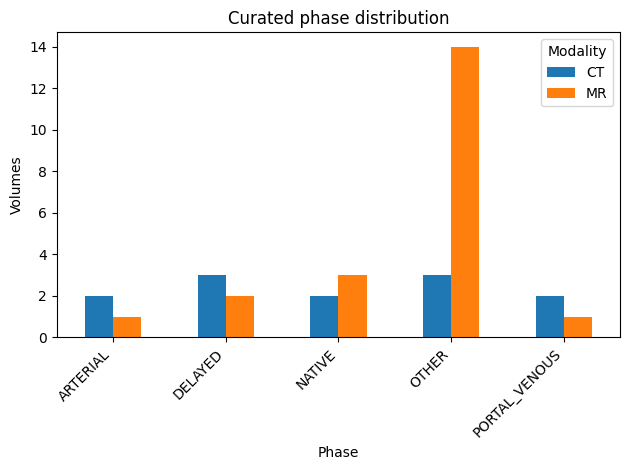

Phase provenance:


,volumes
phase_source,
fallback,17
metadata_phase_candidates,16


Phase status:


,volumes
phase_status,
UNRESOLVED,17
RESOLVED,16


Unresolved CT curation examples (3 total):


...

,patient_key,date,Modality,SeriesDescription,mri_perfusion_source,mri_dynamic_order_source,mri_dynamic_timing_source,mri_dynamic_timing_reliable,mri_sequence,phase,selection_score
3,TCGA-DD-A113,1998-12-24,CT,portal venous 3.0 B40f,NaN,NaN,NaN,NaN,NaN,PORTAL_VENOUS,230.0
10,TCGA-DD-A4NJ,2005-03-24,CT,Portal 3.0 B40f,NaN,NaN,NaN,NaN,NaN,PORTAL_VENOUS,230.0
15,TCGA-DD-A4NJ,2004-03-30,MR,Ax Vibe Post_Portal phase,explicit_text,NaN,NaN,False,T1,PORTAL_VENOUS,230.0
0,TCGA-DD-A113,1998-12-24,CT,late art. phase 3.0 B40f,NaN,NaN,NaN,NaN,NaN,ARTERIAL,225.0
8,TCGA-DD-A4NJ,2005-03-24,CT,Late Arterial 3.0 B40f,NaN,NaN,NaN,NaN,NaN,ARTERIAL,225.0
12,TCGA-DD-A4NJ,2004-03-30,MR,Ax Vibe Post_Arterial phase,explicit_text,NaN,NaN,False,T1,ARTERIAL,225.0
1,TCGA-DD-A113,1998-12-24,CT,Liver @ 10 min 3.0 B40f,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
5,TCGA-DD-A4NJ,2004-02-27,CT,5 MIN DELAY,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
9,TCGA-DD-A4NJ,2005-03-24,CT,180 sec Delay 3.0 B40f,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
13,TCGA-DD-A4NJ,2004-03-30,MR,Ax Vibe Post_Early Delayed phase,explicit_text,NaN,NaN,False,T1,DELAYED,215.0


Lowest-scoring curated selections:


,patient_key,date,Modality,SeriesDescription,mri_perfusion_source,mri_dynamic_order_source,mri_dynamic_timing_source,mri_dynamic_timing_reliable,mri_sequence,phase,selection_score
4,TCGA-DD-A113,1998-12-29,CT,AXIAL,NaN,NaN,NaN,NaN,NaN,OTHER,110.0
7,TCGA-DD-A4NJ,2004-02-27,CT,ENHANCED,NaN,NaN,NaN,NaN,NaN,OTHER,120.0
2,TCGA-DD-A113,1998-12-24,CT,liver w/o 5.0 B40f,NaN,NaN,NaN,NaN,NaN,NATIVE,170.0
11,TCGA-DD-A113,1998-12-09,MR,lava pre,explicit_text,NaN,NaN,False,T1,NATIVE,175.0
14,TCGA-DD-A4NJ,2004-03-30,MR,AX VIBE_Pre,explicit_text,NaN,NaN,False,T1,NATIVE,195.0
6,TCGA-DD-A4NJ,2004-02-27,CT,UNENHANCED,NaN,NaN,NaN,NaN,NaN,NATIVE,200.0
1,TCGA-DD-A113,1998-12-24,CT,Liver @ 10 min 3.0 B40f,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
5,TCGA-DD-A4NJ,2004-02-27,CT,5 MIN DELAY,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
9,TCGA-DD-A4NJ,2005-03-24,CT,180 sec Delay 3.0 B40f,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
13,TCGA-DD-A4NJ,2004-03-30,MR,Ax Vibe Post_Early Delayed phase,explicit_text,NaN,NaN,False,T1,DELAYED,215.0


Selected volumes by patient and modality:


studies  series  volumes  phases
patient_key  Modality                                  
TCGA-DD-A113 CT              2       5        5       5
             MR              1       1        1       1
TCGA-DD-A4NJ CT              2       6        6       5
             MR              1       4        4       4

In [8]:
phased = pd.read_csv('/content/imperandi-demo/tables/dicom_index_phased.csv')
selected = pd.read_csv('/content/imperandi-demo/tables/dicom_index_clean_curated.csv')

phase_counts = (
    phased.groupby(['Modality', 'phase'], dropna=False)
    .size()
    .rename('volumes')
    .reset_index()
)
print('Phase distribution by modality:')
display(phase_counts)

phase_plot = phase_counts.pivot(index='phase', columns='Modality', values='volumes').fillna(0)
ax = phase_plot.plot.bar()
ax.set_xlabel('Phase')
ax.set_ylabel('Volumes')
ax.set_title('Curated phase distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

if 'phase_source' in phased.columns:
    print('Phase provenance:')
    display(phased['phase_source'].value_counts(dropna=False).rename('volumes').to_frame())

if 'phase_status' in phased.columns:
    print('Phase status:')
    display(phased['phase_status'].value_counts(dropna=False).rename('volumes').to_frame())

    unresolved = phased.loc[phased['phase_status'].eq('UNRESOLVED')].copy()

    unresolved_ct = unresolved.loc[unresolved['Modality'].eq('CT')]
    ct_cols = [
        c for c in [
            'patient_key', 'date', 'volume_id', 'SeriesDescription',
            'phase_text_column', 'phase_text_value', 'phase_source', 'phase_reason',
            'rule_phase_reason',
            'ct_phase', 'ct_phase_reason', 'ct_phase_confidence',
            'selection_score', 'phase', 'phase_status'
        ]
        if c in unresolved_ct.columns
    ]
    print(f'Unresolved CT curation examples ({len(unresolved_ct)} total):')
    display(unresolved_ct[ct_cols].head(10))

    unresolved_mr = unresolved.loc[unresolved['Modality'].isin(['MR', 'MRI'])]
    mr_cols = [
        c for c in [
            'patient_key', 'date', 'volume_id', 'SeriesDescription',
            'phase_text_column', 'phase_text_value', 'phase_source', 'phase_reason',
            'rule_phase_reason',
            'mri_perfusion_source', 'mri_dynamic_order_source',
            'mri_dynamic_timing_source', 'mri_dynamic_timing_reliable',
            'mri_sequence', 'plane',
            'mri_perfusion_label', 'mri_perfusion_reason',
            'mri_perfusion_confidence',
            't1_score', 't2_score', 'dwi_score', 'selection_score',
            'phase', 'phase_status'
        ]
        if c in unresolved_mr.columns
    ]
    print(f'Unresolved MR curation examples ({len(unresolved_mr)} total):')
    display(unresolved_mr[mr_cols].head(10))

if 'phase_source' in phased.columns:
    resolved = (phased['phase_status'].eq('RESOLVED') & phased['phase_source'].eq('metadata_phase_candidates')).sum()
    print(f'Metadata-resolved phases: {resolved}/{len(phased)}')
    assert resolved > 0, 'No phases were resolved from metadata; inspect qc_unresolved_phase.csv.'

selected['selection_score'] = pd.to_numeric(selected['selection_score'], errors='coerce')
scores = selected['selection_score'].dropna()
print(f'Best-per-exam curated rows: {len(selected)}')

curated_cols = [
    c for c in [
        'patient_key', 'date', 'Modality', 'SeriesDescription',
        'mri_perfusion_source', 'mri_dynamic_order_source',
            'mri_dynamic_timing_source', 'mri_dynamic_timing_reliable',
            'mri_sequence', 'phase', 'selection_score'
    ]
    if c in selected.columns
]
ranked = selected.dropna(subset=['selection_score'])

print('Highest-scoring curated selections:')
display(ranked.nlargest(10, 'selection_score')[curated_cols])

print('Lowest-scoring curated selections:')
display(ranked.nsmallest(10, 'selection_score')[curated_cols])

print('Selected volumes by patient and modality:')
display(
    selected.groupby(['patient_key', 'Modality'])
    .agg(
        studies=('study_id', 'nunique'),
        series=('series_id', 'nunique'),
        volumes=('volume_id', 'nunique'),
    )
)

## What this demonstrated

The light workflow stops here: public heterogeneous DICOMs → standardized identifiers → reconstructed volumes → phase/sequence annotation → reviewable best-candidate selection. The full notebook continues with NIfTI conversion, segmentation, and interactive visual QC.